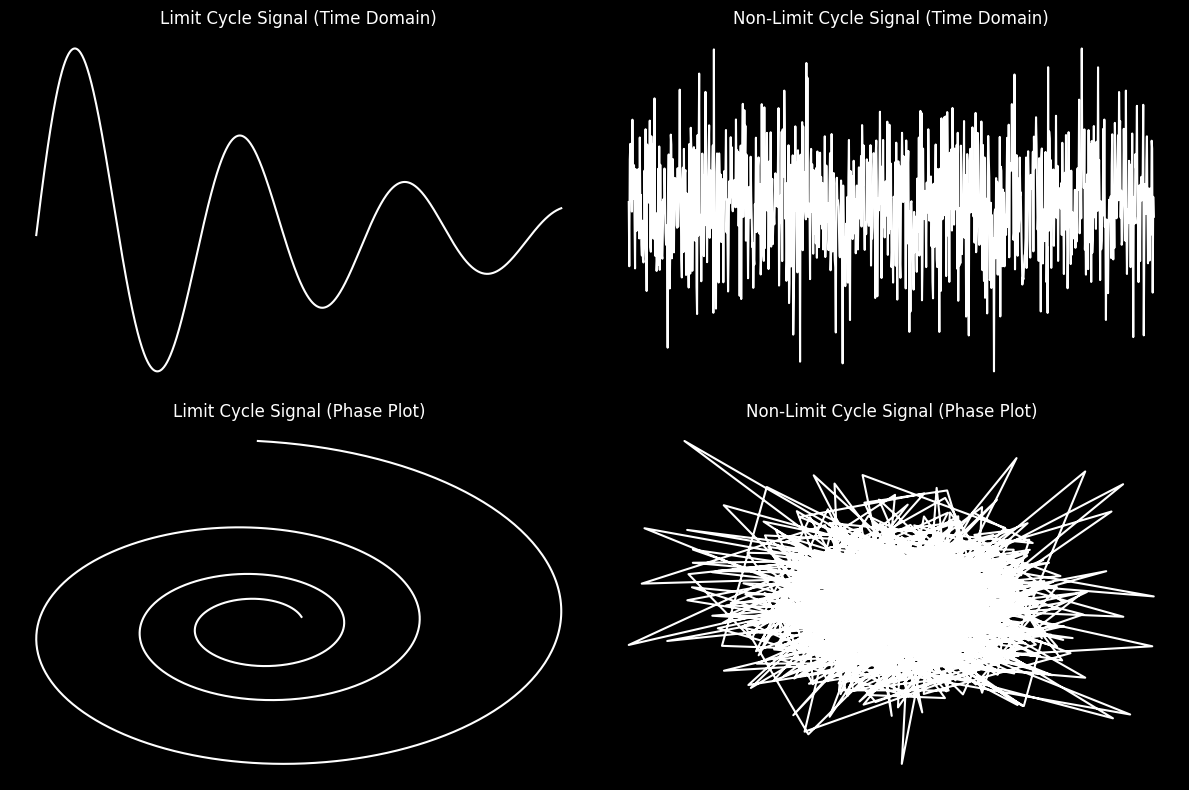

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Time range
t = np.linspace(0, 20, 1000)

# Limit cycle signal (e.g., sustained oscillations)
x_limit =np.sin(t) * np.exp(-0.1 * t)
y_limit = np.cos(t) * np.exp(-0.1 * t)

# Non-limit cycle signal (e.g., decaying oscillations)
x_nonlimit = np.random.normal(0, 1, size=t.size)
y_nonlimit = np.random.normal(0, 1, size=t.size)


# Setting the plot style for white on black
plt.style.use('dark_background')

# Plotting both signals
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# Time-domain plots
ax[0, 0].plot(t, x_limit, color='white', label='Limit Cycle')
ax[0, 0].set_title('Limit Cycle Signal (Time Domain)', color='white')
#ax[0, 0].set_xlabel('Time', color='white')
#ax[0, 0].set_ylabel('Amplitude', color='white')
#ax[0, 0].legend()
ax[0, 0].axis('off')  # Turn off axis for the limit cycle time-domain plot

ax[0, 1].plot(t, x_nonlimit, color='white', label='Non-Limit Cycle')
ax[0, 1].set_title('Non-Limit Cycle Signal (Time Domain)', color='white')
#ax[0, 1].set_xlabel('Time', color='white')
#ax[0, 1].set_ylabel('Amplitude', color='white')
#ax[0, 1].legend()
ax[0, 1].axis('off')  # Turn off axis for the limit cycle time-domain plot

# Phase plots
ax[1, 0].plot(x_limit, y_limit, color='white')
ax[1, 0].set_title('Limit Cycle Signal (Phase Plot)', color='white')
#ax[1, 0].set_xlabel('x(t)', color='white')
#ax[1, 0].set_ylabel('y(t)', color='white')
ax[1, 0].axis('off')  # Turn off axis for the limit cycle time-domain plot

ax[1, 1].plot(x_nonlimit, y_nonlimit, color='white')
ax[1, 1].set_title('Non-Limit Cycle Signal (Phase Plot)', color='white')
#ax[1, 1].set_xlabel('x(t)', color='white')
#ax[1, 1].set_ylabel('y(t)', color='white')
ax[1, 1].axis('off')  # Turn off axis for the limit cycle time-domain plot

# Adjust subplot spacing
plt.tight_layout()

# Show plots
plt.show()


/var/folders/vq/88w0fsrd38jfcb709k99p0kjfx13h1/T/ipykernel_38784/2207182091.py:22: RuntimeWarning: divide by zero encountered in log
  freqs= np.log(freqs[mask])


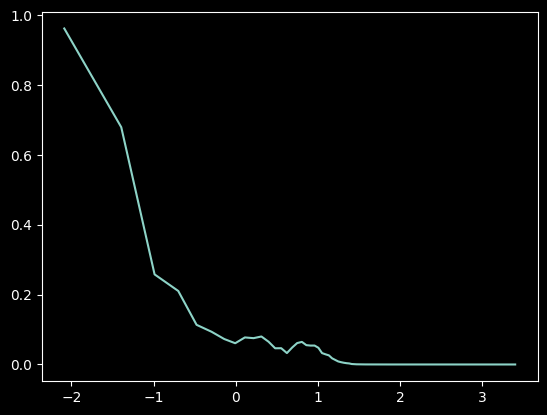

/var/folders/vq/88w0fsrd38jfcb709k99p0kjfx13h1/T/ipykernel_38784/2207182091.py:27: RuntimeWarning: divide by zero encountered in log
  freqs_= np.log(freqs_[mask_])


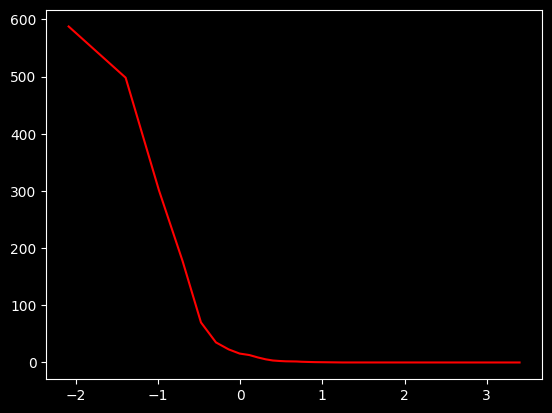

In [53]:
import pandas as pd
import metrics_analysis as m_a
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.signal import welch, butter, filtfilt, resample

# Constants

ORIGINAL_RATE = 1017.252625
ch_405_ds=pd.read_csv("/Users/reva/Documents/Python/SE_DA_FPM/data/ch_405_VS.csv")
ch_407_ds=pd.read_csv("/Users/reva/Documents/Python/SE_DA_FPM/data/ch_470_VS.csv")
max_nperseg = len(ch_405_ds.values.flatten())/8

nperseg = 2 ** int(np.floor(np.log2(max_nperseg))) # Smaller segment size
max_freq=30
noverlap = nperseg * 3 // 4
freqs, power = welch(ch_405_ds.values.flatten(), ORIGINAL_RATE, nperseg=nperseg, noverlap=noverlap)
freqs_, power_ = welch(ch_407_ds.values.flatten(), ORIGINAL_RATE, nperseg=nperseg, noverlap=noverlap)

# Focus on the very low frequencies, up to max_freq Hz
mask = freqs <= max_freq
freqs= np.log(freqs[mask])
power_dB = power[mask]
plt.plot(freqs, power_dB)
plt.show()
mask_ = freqs_ <= max_freq
freqs_= np.log(freqs_[mask_])
power_dB_ = power_[mask_]


plt.plot(freqs_, power_dB_, "r")
plt.show()

8192